# Prática: Gerador de Números Aleatórios - Random Walk 1D

Simulação de **10 caminhadas aleatórias unidimensionais** com **10.000 passos** cada,
usando um **Gerador Congruencial Linear (LCG)** implementado manualmente.

## Fluxo de trabalho

| Etapa | Descrição |
|---|---|
| 1 | Implementação manual do LCG e funções auxiliares |
| 2 | Simulação das caminhadas com o LCG |
| 3 | Visualização geral das 10 trajetórias |
| 4 | Função teórica $P_n(d)$ e comparação individual |
| 5 | Análise individual: trajetória + histograma de visitas + Gaussiana |
| 6 | Monte Carlo: distribuição empírica vs. teórica vs. Gaussiana |

## Modelo Teórico

**Random Walk simples em 1D**:

$$S_N = \sum_{i=1}^{N} X_i, \quad X_i \in \{-1,+1\}, \quad P(X_i=+1)=P(X_i=-1)=\frac{1}{2}$$

Probabilidade teórica de deslocamento final $d$ após $N$ passos:

$$P_N(d)=\frac{1}{2^N}\binom{N}{\frac{N+d}{2}}$$

Válida quando $N+d$ é par e $|d|\leq N$.

Propriedades:

$$\langle S_N \rangle=0, \quad \langle S_N^2 \rangle=N, \quad \sigma_N=\sqrt{N}$$

Para $N$ grande, a aproximação gaussiana é:

$$P_N(d) \approx \frac{2}{\sqrt{2\pi N}}\exp\!\left(-\frac{d^2}{2N}\right)$$

---
## Etapa 1 - Implementação Manual do LCG

Recorrência usada:

$$X_{n+1} = (A \cdot X_n + B) \bmod M, \qquad U_n = \frac{X_n}{M}$$

Parâmetros dos slides:

- $A=843314861$
- $B=453816693$
- $M=1073741824=2^{30}$

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Parametros LCG (dos slides)
LCG_A = 843314861
LCG_B = 453816693
LCG_M = 1073741824
LCG_SEED = 123456789


def lcg_gerar(n: int, semente: int):
    """Gera n uniformes em [0,1) e retorna tambem o estado final."""
    uniforms = np.empty(n, dtype=np.float64)
    x = int(semente)
    for i in range(n):
        x = (LCG_A * x + LCG_B) % LCG_M
        if x < 0:
            x += LCG_M
        uniforms[i] = x / LCG_M
    return uniforms, x


def uniformes_para_passos(uniforms: np.ndarray) -> np.ndarray:
    """Mapeia U<0.5 para -1 e U>=0.5 para +1."""
    return np.where(uniforms < 0.5, -1, 1)


n_walks = 10
n_steps = 10_000

print(f"LCG: A={LCG_A}, B={LCG_B}, M={LCG_M}, seed={LCG_SEED}")
print(f"Configuracao: {n_walks} caminhadas x {n_steps} passos")

LCG: A=843314861, B=453816693, M=1073741824, seed=123456789
Configuracao: 10 caminhadas x 10000 passos


---
## Etapa 2 - Simulação das Caminhadas com o LCG

Geramos $n_{walks} \times n_{steps}$ uniformes com o LCG, mapeamos para passos $\{-1,+1\}$ e calculamos $S_t$ por soma acumulada.

In [2]:
# Gera todos os passos de uma vez via LCG
n_total = n_walks * n_steps
uniforms_todos, estado_final = lcg_gerar(n_total, LCG_SEED)
steps = uniformes_para_passos(uniforms_todos).reshape(n_walks, n_steps)

# Soma acumulada para obter posicoes S_t
positions = np.cumsum(steps, axis=1)
positions = np.hstack([np.zeros((n_walks, 1), dtype=int), positions])

# Deslocamento final de cada caminhada
final_displacements = positions[:, -1]

sigma_teo = np.sqrt(n_steps)
print("Deslocamentos finais:")
for i, d in enumerate(final_displacements, start=1):
    print(f"  Caminhada {i:2d}: d = {int(d):+6d} ({abs(d)/sigma_teo:.2f}σ)")

Deslocamentos finais:
  Caminhada  1: d =   -124 (1.24σ)
  Caminhada  2: d =    +14 (0.14σ)
  Caminhada  3: d =   +116 (1.16σ)
  Caminhada  4: d =    +26 (0.26σ)
  Caminhada  5: d =     -2 (0.02σ)
  Caminhada  6: d =    +70 (0.70σ)
  Caminhada  7: d =     +8 (0.08σ)
  Caminhada  8: d =    +42 (0.42σ)
  Caminhada  9: d =    +76 (0.76σ)
  Caminhada 10: d =   -174 (1.74σ)


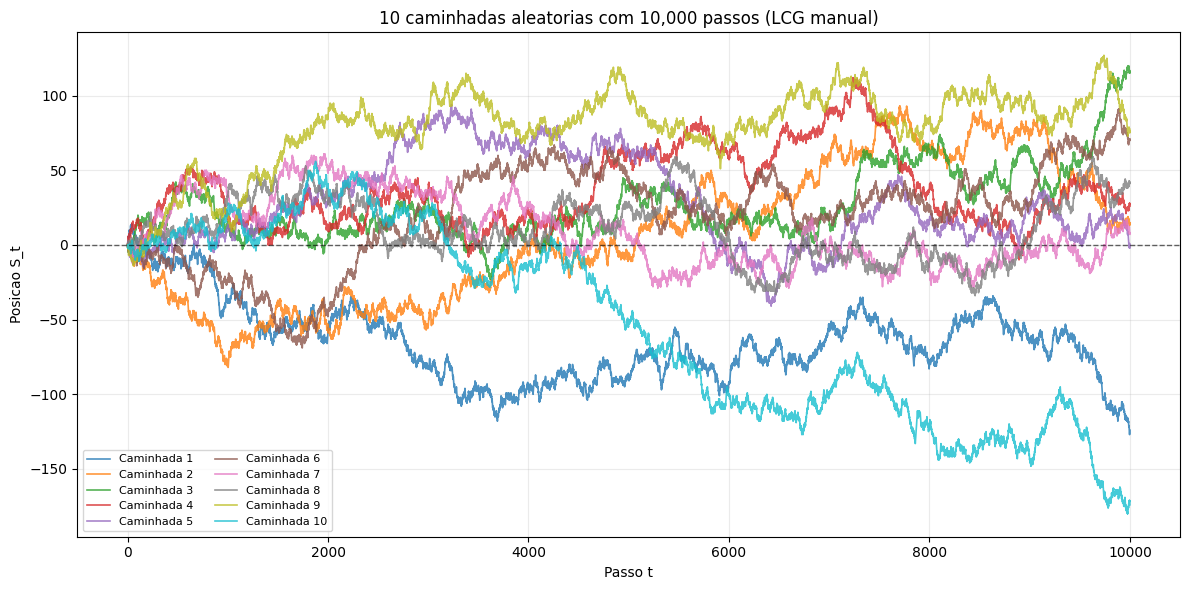

In [3]:
# Etapa 3 - Visualizacao geral das trajetorias
plt.figure(figsize=(12, 6))

for i in range(n_walks):
    plt.plot(positions[i], alpha=0.8, linewidth=1.2, label=f'Caminhada {i+1}')

plt.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.6)
plt.title(f'10 caminhadas aleatorias com {n_steps:,} passos (LCG manual)')
plt.xlabel('Passo t')
plt.ylabel('Posicao S_t')
plt.legend(ncol=2, fontsize=8)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

---
## Etapa 4 - Probabilidade Teórica $P_N(d)$

Para evitar overflow em $N=10.000$, usamos `math.lgamma` para calcular log-fatoriais.

In [4]:
def p_n_d(n: int, d: int) -> float:
    """Probabilidade teorica de deslocamento final d apos n passos."""
    if abs(d) > n:
        return 0.0
    if (n + d) % 2 != 0:
        return 0.0

    k = (n + d) // 2
    log_p = (
        math.lgamma(n + 1)
        - math.lgamma(k + 1)
        - math.lgamma(n - k + 1)
        - n * math.log(2)
    )
    return math.exp(log_p)


sigma_teo = np.sqrt(n_steps)
print(f"{'Caminhada':>10} | {'d observado':>12} | {'P_N(d) teorico':>16} | {'|d|/sigma':>8}")
print('-' * 62)
for i, d in enumerate(final_displacements, start=1):
    p = p_n_d(n_steps, int(d))
    print(f"{i:>10} | {int(d):>+12d} | {p:>16.3e} | {abs(d)/sigma_teo:>7.2f}")

 Caminhada |  d observado |   P_N(d) teorico | |d|/sigma
--------------------------------------------------------------
         1 |         -124 |        3.699e-03 |    1.24
         2 |          +14 |        7.901e-03 |    0.14
         3 |         +116 |        4.072e-03 |    1.16
         4 |          +26 |        7.714e-03 |    0.26
         5 |           -2 |        7.977e-03 |    0.02
         6 |          +70 |        6.245e-03 |    0.70
         7 |           +8 |        7.953e-03 |    0.08
         8 |          +42 |        7.305e-03 |    0.42
         9 |          +76 |        5.977e-03 |    0.76
        10 |         -174 |        1.756e-03 |    1.74


---
## Etapa 5 - Análise Individual

Para cada caminhada: trajetória e histograma de visitas por posição, com sobreposição de gaussiana ajustada.

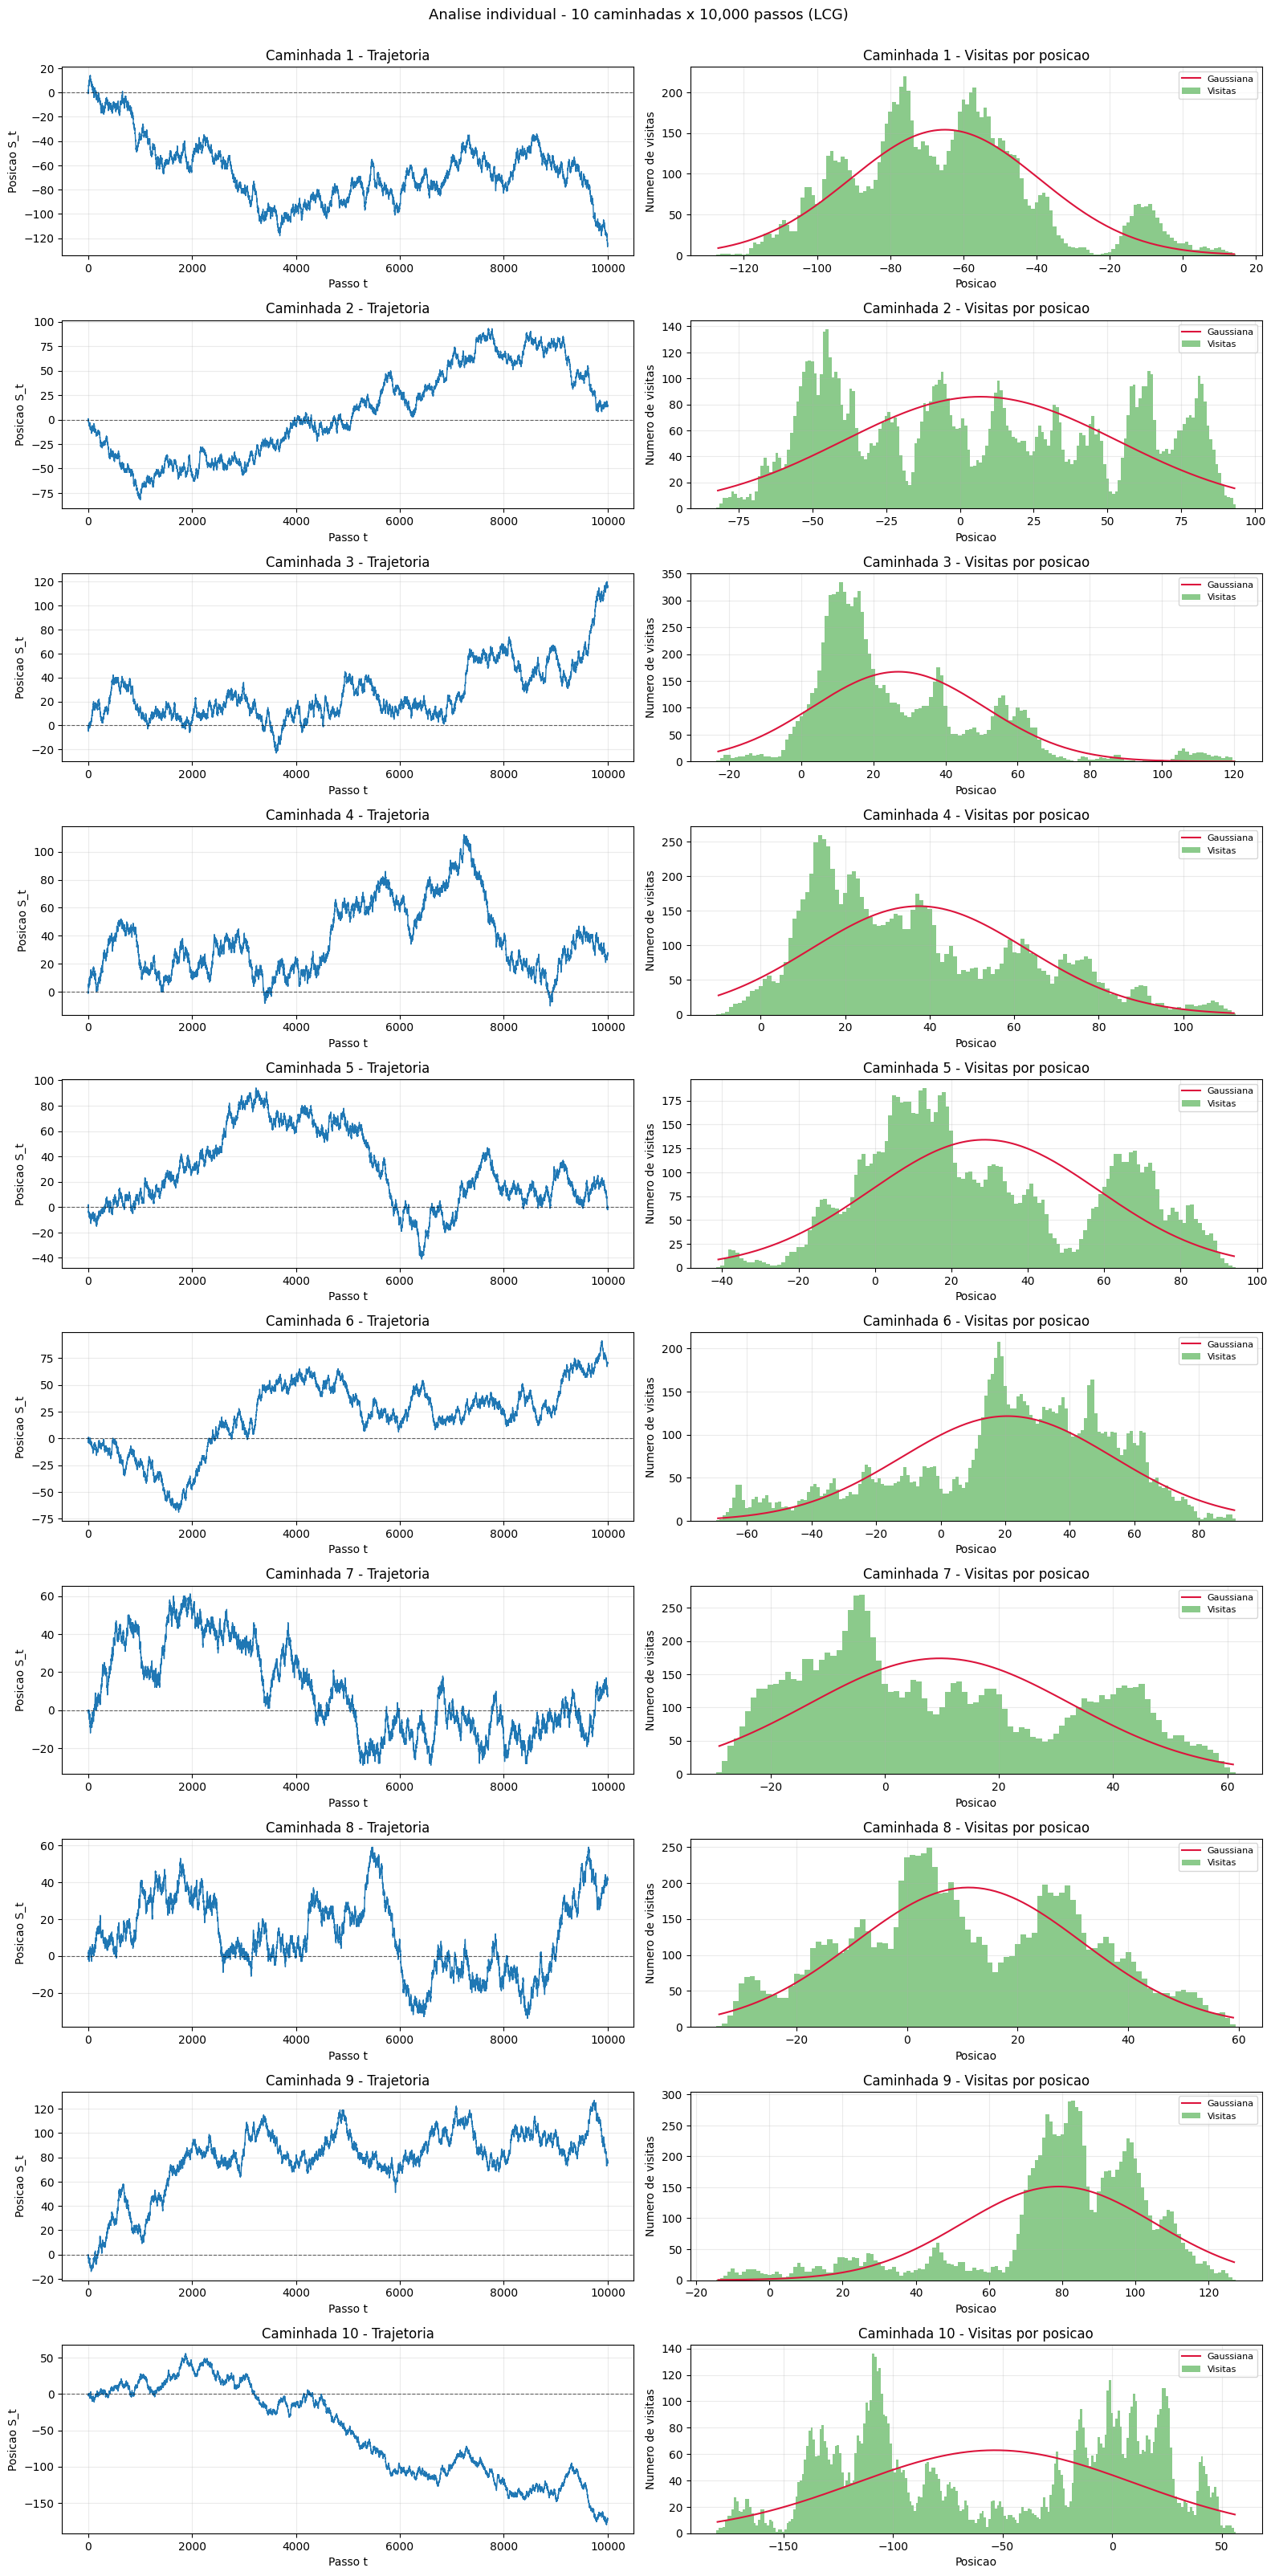

In [5]:
fig, axes = plt.subplots(n_walks, 2, figsize=(16, 3.2 * n_walks))

for i in range(n_walks):
    traj = positions[i]

    # Painel esquerdo: trajetoria
    axes[i, 0].plot(traj, color='tab:blue', linewidth=1.0)
    axes[i, 0].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.6)
    axes[i, 0].set_title(f'Caminhada {i+1} - Trajetoria')
    axes[i, 0].set_xlabel('Passo t')
    axes[i, 0].set_ylabel('Posicao S_t')
    axes[i, 0].grid(alpha=0.25)

    # Painel direito: histograma de visitas por posicao
    vals_visit, counts_visit = np.unique(traj, return_counts=True)
    mu = traj.mean()
    sigma = traj.std(ddof=0)

    axes[i, 1].bar(vals_visit, counts_visit, width=1.0, alpha=0.55, color='tab:green', label='Visitas')

    if sigma > 0:
        x = np.arange(vals_visit.min(), vals_visit.max() + 1)
        gaussian_pdf = (1.0 / (sigma * np.sqrt(2.0 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
        gaussian_counts = gaussian_pdf * len(traj)
        axes[i, 1].plot(x, gaussian_counts, color='crimson', linewidth=1.5, label='Gaussiana')

    axes[i, 1].set_title(f'Caminhada {i+1} - Visitas por posicao')
    axes[i, 1].set_xlabel('Posicao')
    axes[i, 1].set_ylabel('Numero de visitas')
    axes[i, 1].grid(alpha=0.25)
    axes[i, 1].legend(fontsize=8)

plt.suptitle(f'Analise individual - {n_walks} caminhadas x {n_steps:,} passos (LCG)', fontsize=13, y=1.001)
plt.tight_layout()
plt.show()

---
## Etapa 6 - Monte Carlo com LCG Manual

Aqui nao usamos `rng.binomial`. Cada deslocamento final e obtido de passos gerados pelo LCG, mantendo a implementacao manual do gerador.

Simulando 1000 caminhadas de 10000 passos via LCG...


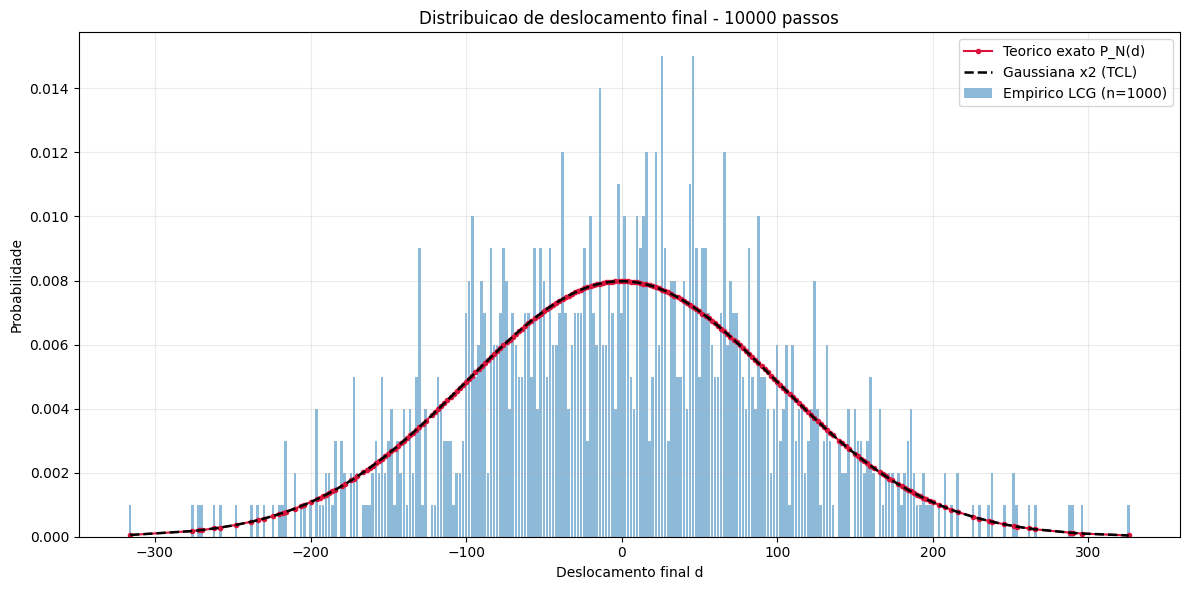

Erro maximo empirico vs teorico: 7.822e-03
Erro maximo teorico vs gaussiana: 1.995e-07


In [6]:
# Nota: n_mc reduzido para manter desempenho em Python puro
n_mc = 1_000

print(f"Simulando {n_mc} caminhadas de {n_steps} passos via LCG...")

# Continua o estado do LCG para nao repetir a mesma sequencia da etapa anterior
uniforms_mc, _ = lcg_gerar(n_mc * n_steps, estado_final)
steps_mc = uniformes_para_passos(uniforms_mc).reshape(n_mc, n_steps)
final_mc = steps_mc.sum(axis=1)

vals, counts = np.unique(final_mc, return_counts=True)
empirical_probs = counts / n_mc
theoretical_probs = np.array([p_n_d(n_steps, int(d)) for d in vals])

sigma_rw = np.sqrt(n_steps)
normal_pdf = (1.0 / (sigma_rw * np.sqrt(2.0 * np.pi))) * np.exp(-0.5 * (vals / sigma_rw) ** 2)
normal_approx = 2.0 * normal_pdf

plt.figure(figsize=(12, 6))
plt.bar(vals, empirical_probs, width=1.6, alpha=0.5, label=f'Empirico LCG (n={n_mc})')
plt.plot(vals, theoretical_probs, 'o-', color='crimson', linewidth=1.5, markersize=3, label='Teorico exato P_N(d)')
plt.plot(vals, normal_approx, '--', color='black', linewidth=1.8, label='Gaussiana x2 (TCL)')
plt.title(f'Distribuicao de deslocamento final - {n_steps} passos')
plt.xlabel('Deslocamento final d')
plt.ylabel('Probabilidade')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

erro_emp = np.max(np.abs(empirical_probs - theoretical_probs))
erro_gauss = np.max(np.abs(theoretical_probs - normal_approx))
print(f"Erro maximo empirico vs teorico: {erro_emp:.3e}")
print(f"Erro maximo teorico vs gaussiana: {erro_gauss:.3e}")

---
## Referências

- Slides `pmmat_aula07.pdf`: parâmetros do LCG e função `aleat()`.
- Slides `numerosaleatorios.pdf`: geradores congruenciais e aplicações.
- Random Walk 1D: distribuição binomial e aproximação gaussiana (TCL).